In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

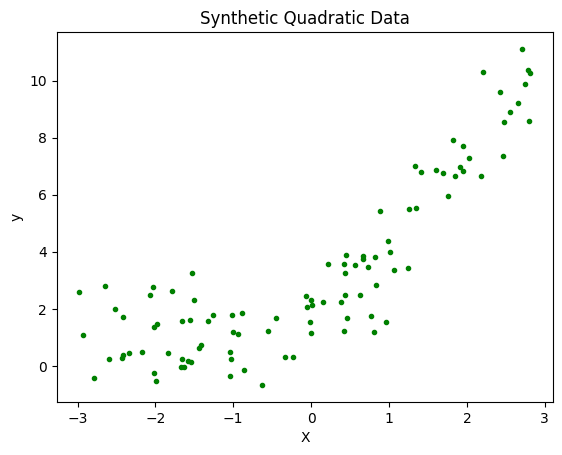

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100, 1)

plt.plot(X, y, "g.")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Quadratic Data")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
from sklearn.metrics import mean_squared_error, r2_score
score = r2_score(y_test, regression.predict(X_test)) #* Y_test mean given marks vs predicted marks
print("R2 Score:", score)

R2 Score: 0.763191783366047


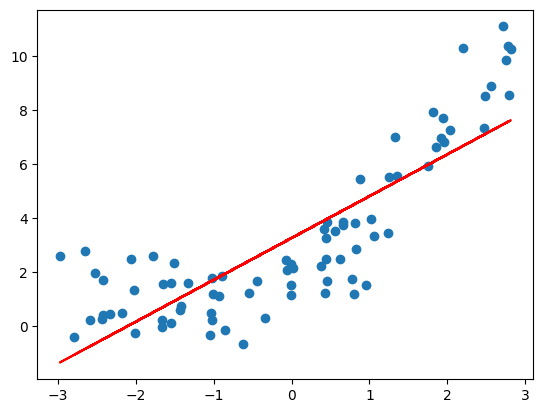

In [6]:
plt.plot(X_train,regression.predict(X_train),color='red')
plt.scatter(X_train,y_train)

# Polinomial regression

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias = True)
X_poly = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [8]:
regression = LinearRegression()
regression.fit(X_poly, y_train)
y_pred = regression.predict(X_test)
score = r2_score(y_test, y_pred)
print("R2 Score after Polynomial Features:", score)

R2 Score after Polynomial Features: 0.8645099579835541


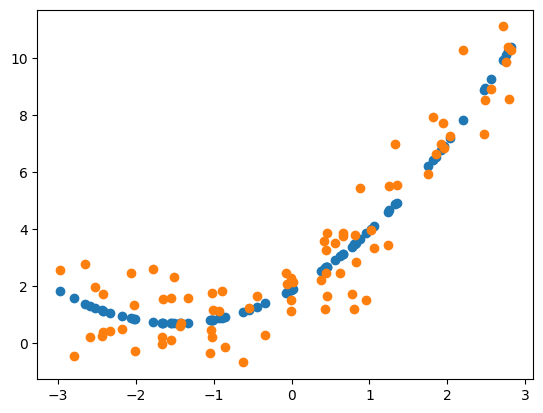

In [9]:
plt.scatter(X_train,regression.predict(X_poly))
plt.scatter(X_train,y_train)

In [10]:
#* prediction of new data
new_data = np.linspace(-3, 3, 100).reshape(100, 1)
new_data_poly = poly.transform(new_data)
predictions = regression.predict(new_data_poly)
predictions

array([[ 1.87969589],
       [ 1.78699225],
       [ 1.69811078],
       [ 1.61305149],
       [ 1.53181437],
       [ 1.45439942],
       [ 1.38080665],
       [ 1.31103606],
       [ 1.24508764],
       [ 1.1829614 ],
       [ 1.12465733],
       [ 1.07017543],
       [ 1.01951572],
       [ 0.97267817],
       [ 0.9296628 ],
       [ 0.89046961],
       [ 0.85509859],
       [ 0.82354975],
       [ 0.79582308],
       [ 0.77191859],
       [ 0.75183627],
       [ 0.73557613],
       [ 0.72313816],
       [ 0.71452237],
       [ 0.70972876],
       [ 0.70875731],
       [ 0.71160805],
       [ 0.71828096],
       [ 0.72877604],
       [ 0.7430933 ],
       [ 0.76123273],
       [ 0.78319434],
       [ 0.80897813],
       [ 0.83858408],
       [ 0.87201222],
       [ 0.90926253],
       [ 0.95033501],
       [ 0.99522967],
       [ 1.04394651],
       [ 1.09648552],
       [ 1.1528467 ],
       [ 1.21303006],
       [ 1.2770356 ],
       [ 1.34486331],
       [ 1.4165132 ],
       [ 1

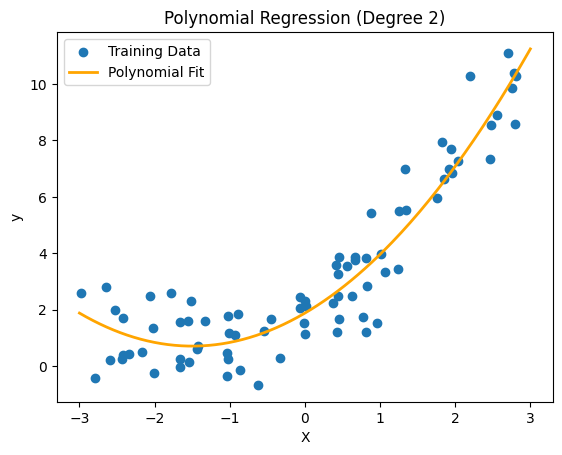

In [11]:
# Create smooth new data
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = regression.predict(X_new_poly)

plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_new, y_new, color='orange', linewidth=2, label="Polynomial Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()
